In [1]:
import numpy as np
import pandas as pd

from scformer.utils import *
from scformer.model import *
from warnings import filterwarnings
import random
import os
import torch
import torch.cuda as cuda
from scipy import sparse
import scanpy as sc
import anndata as ad
from scipy.sparse import csr_matrix
from scipy.io import mmread


In [2]:
# 读取稀疏矩阵文件
matrix = mmread('data/pan_cancer/matrix.mtx')

In [3]:
compress_matrix = csr_matrix(matrix)
compress_matrix

<18315x42099 sparse matrix of type '<class 'numpy.int64'>'
	with 66708974 stored elements in Compressed Sparse Row format>

In [4]:
# 读取 barcodes 和 features 文件
barcodes = pd.read_csv('data/pan_cancer/barcodes.tsv', header=None)
features = pd.read_csv('data/pan_cancer/features.tsv', header=None)

barcodes.shape, features.shape

((42099, 1), (18315, 1))

In [5]:
adata = sc.AnnData(X=compress_matrix.transpose())
adata.var_names = features[0].values
adata.obs_names = barcodes[0].values
adata

C:\Users\Administrator\AppData\Local\Temp\ipykernel_15000\549244909.py:1: FutureWarning: X.dtype being converted to np.float32 from int64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata = sc.AnnData(X=compress_matrix.transpose())


AnnData object with n_obs × n_vars = 42099 × 18315

In [6]:
metadata = pd.read_csv('data/pan_cancer/metadata.tsv', sep='\t')
metadata.head()

,SampleID,PatientID,Cancer,Tissue,Tumor_stage,Annotation
AAACCTGTCCTCAACC-88_D36_UCEC.P20190312_N_Pre,D36_UCEC.P20190312_N_Pre,D36_UCEC.P20190312,UCEC,Adjacent non-tumor tissue,I,c16_PC_IGHG
AAACCTGTCCTTTCGG-88_D36_UCEC.P20190312_N_Pre,D36_UCEC.P20190312_N_Pre,D36_UCEC.P20190312,UCEC,Adjacent non-tumor tissue,I,c16_PC_IGHG
AAACGGGTCCTGCCAT-88_D36_UCEC.P20190312_N_Pre,D36_UCEC.P20190312_N_Pre,D36_UCEC.P20190312,UCEC,Adjacent non-tumor tissue,I,c17_PC_IGHA
AAAGCAAAGTCCATAC-88_D36_UCEC.P20190312_N_Pre,D36_UCEC.P20190312_N_Pre,D36_UCEC.P20190312,UCEC,Adjacent non-tumor tissue,I,c16_PC_IGHG
AAAGCAATCATCTGTT-88_D36_UCEC.P20190312_N_Pre,D36_UCEC.P20190312_N_Pre,D36_UCEC.P20190312,UCEC,Adjacent non-tumor tissue,I,c04_classical-Bm_TXNIP


In [7]:
adata.obs = metadata
adata

AnnData object with n_obs × n_vars = 42099 × 18315
    obs: 'SampleID', 'PatientID', 'Cancer', 'Tissue', 'Tumor_stage', 'Annotation'

In [8]:
adata.write('cache/pan_cancer_matrix.h5ad')

In [9]:
adata = sc.read_h5ad('cache/pan_cancer_matrix.h5ad')
adata

AnnData object with n_obs × n_vars = 42099 × 18315
    obs: 'SampleID', 'PatientID', 'Cancer', 'Tissue', 'Tumor_stage', 'Annotation'

In [10]:
adata.obs['Cancer'].unique()

['UCEC', 'THCA', 'RC', 'PACA', 'OV', 'FTC', 'ESCA', 'BRCA']
Categories (8, object): ['BRCA', 'ESCA', 'FTC', 'OV', 'PACA', 'RC', 'THCA', 'UCEC']

In [11]:
adata.obs['PatientID'].unique()

['D36_UCEC.P20190312', 'D36_UCEC.P20181122', 'D36_UCEC.P20190213', 'D36_UCEC.P20190305', 'D36_UCEC.P20190625', ..., 'D36_ESCA.P20190613', 'D36_ESCA.P20190916', 'D36_ESCA.P20191129', 'D36_BC.P20190403', 'D36_BC.P20190123']
Length: 49
Categories (49, object): ['D36_BC.P20190123', 'D36_BC.P20190403', 'D36_ESCA.P20181114', 'D36_ESCA.P20181123', ..., 'D36_UCEC.P20190717', 'D36_UCEC.P20190722', 'D36_UCEC.P20190910', 'D36_UCEC.P20190911']

In [13]:
adata_ESCA = adata[adata.obs['Cancer'] == 'ESCA']
adata_ESCA

View of AnnData object with n_obs × n_vars = 11640 × 18315
    obs: 'SampleID', 'PatientID', 'Cancer', 'Tissue', 'Tumor_stage', 'Annotation'

In [14]:
PatientID = adata_ESCA.obs['PatientID'].unique()

In [15]:
adata_ESCA_train = adata_ESCA[adata_ESCA.obs['PatientID'].isin(list(PatientID)[0:8])]
adata_ESCA_train

View of AnnData object with n_obs × n_vars = 10886 × 18315
    obs: 'SampleID', 'PatientID', 'Cancer', 'Tissue', 'Tumor_stage', 'Annotation'

In [16]:
adata_ESCA_test = adata_ESCA[adata_ESCA.obs['PatientID'] == PatientID[8]]
adata_ESCA_test

View of AnnData object with n_obs × n_vars = 754 × 18315
    obs: 'SampleID', 'PatientID', 'Cancer', 'Tissue', 'Tumor_stage', 'Annotation'

In [20]:
RNA_matrix = adata_ESCA_train.X.transpose()

cell_num = RNA_matrix.shape[1]
gene_num = RNA_matrix.shape[0]

cell_num, gene_num

(10886, 18315)

In [21]:
initial_pre = initial_clustering(RNA_matrix)

cluster_ini_num = len(set(initial_pre))
ini_p1 = [int(i) for i in initial_pre]
# partite the data into batches
indices, Node_Ids, dic = batch_select_whole(RNA_matrix)
n_batch = len(indices)

	When the number of cells is less than or equal to 500, it is recommended to set the resolution value to 0.2.
	When the number of cells is within the range of 500 to 5000, the resolution value should be set to 0.5.
	When the number of cells is greater than 5000, the resolution value should be set to 0.8.
         Falling back to preprocessing with `sc.pp.pca` and default params.


C:\ProgramData\anaconda3\envs\scrna\lib\site-packages\umap\distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
C:\ProgramData\anaconda3\envs\scrna\lib\site-packages\umap\distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
C:\ProgramData\anaconda3\envs\scrna\lib\site-packages\umap\distances.py:1086: NumbaDepreca

Partitioning the data into batches. Please wait...


Processing Batches: 100%|██████████| 363/363 [04:07<00:00,  1.47it/s]


In [22]:
device = torch.device("cuda" if cuda.is_available() else "cpu")
node_model = NodeDimensionReduction(RNA_matrix, indices, ini_p1, n_hid=104, n_heads=8,
                                    n_layers=3, labsm=0.1, lr=0.0005, wd=0.1, device=device, num_types=2,
                                    num_relations=2, epochs=100)
gnn, cell_emb, gene_emb, h = node_model.train_model(n_batch=n_batch)

The training process for the NodeDimensionReduction model has started. Please wait.


  0%|          | 0/100 [00:00<?, ?it/s]C:\ProgramData\anaconda3\envs\scrna\lib\site-packages\torch\nn\functional.py:2943: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  warnings.warn(
100%|██████████| 100/100 [1:13:12<00:00, 43.92s/it]

The training for the NodeDimensionReduction model has been completed.


In [23]:
ScFormer_model = ScFormer(gnn=gnn, h=h, labsm=0.1, n_hid=104, n_batch=n_batch, device=device, lr=0.0005, wd=0.1,
                          num_epochs=50)
ScFormer_gnn, _, _, _ = ScFormer_model.train_model(indices=indices, RNA_matrix=RNA_matrix, ini_p1=ini_p1)
ScFormer_model.save_model('scformer_model.pth')

The training process for the scformer model has started. Please wait.
Forward pass started.


Epochs: 100%|██████████| 50/50 [43:42<00:00, 52.45s/it]

The training for the scformer model has been completed.
The training for the scformer model has been completed.


In [24]:
ScFormer_result = ScFormer_pred(RNA_matrix, gnn=ScFormer_gnn, indices=indices,
                                nodes_id=Node_Ids, device=device)
# Save numpy arrays to files
output_file = 'data/pan_cancer/output/ESCA'
os.makedirs(output_file, exist_ok=True)
np.save(output_file + "/Node_Ids.npy", Node_Ids)
np.save(output_file + "/pred.npy", ScFormer_result['pred_label'])
np.save(output_file + "/cell_embedding.npy", ScFormer_result['cell_embedding'])

Prediction Batches: 100%|██████████| 363/363 [00:38<00:00,  9.31it/s]


In [17]:
Node_Ids = np.load('data/pan_cancer/output/ESCA/Node_Ids.npy')

cell_emb = np.load('data/pan_cancer/output/ESCA/cell_embedding.npy')
cell_emb_ = pd.DataFrame(cell_emb, index=Node_Ids)
cell_emb_

,0,1,2,3,4,5,6,7,8,9,...,94,95,96,97,98,99,100,101,102,103
8901,-2.081668,1.307182,4.352293,-1.518728,-2.093502,-2.323308,-1.904628,-1.194107,-1.158326,-1.599610,...,-2.734315,-2.749101,-2.746177,-2.747455,-2.739824,-2.745902,-2.748275,-2.744884,-2.746033,-2.746251
644,-1.624913,-1.012010,-0.853517,-0.661253,-2.269495,-2.084122,-2.146820,4.318911,-1.090807,-1.821037,...,-2.703936,-2.743482,-2.746156,-2.748463,-2.755312,-2.746034,-2.744479,-2.746768,-2.746054,-2.745913
9025,4.589032,-1.543721,-1.719573,-1.854462,-1.923024,-1.953521,-2.034724,-1.659129,-2.007184,-1.841452,...,-2.796159,-2.743174,-2.746231,-2.744504,-2.741230,-2.746498,-2.739946,-2.749205,-2.746070,-2.745862
9105,-2.448410,3.796560,1.671970,-2.248824,-1.824261,-2.343986,-2.046276,-1.490960,-0.852277,-1.990105,...,-2.641663,-2.749791,-2.746178,-2.745074,-2.744681,-2.746158,-2.740117,-2.748136,-2.746069,-2.746386
1237,-1.538293,-1.399858,-1.174131,-1.406318,-1.157046,-1.475435,-1.924794,-1.090166,-1.479941,-1.974416,...,-2.693380,-2.746338,-2.746223,-2.747725,-2.745224,-2.746087,-2.747751,-2.744588,-2.746033,-2.746223
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
534,-2.115643,0.380555,0.825488,-2.213766,-2.140330,-2.244806,-2.039244,-2.005126,-1.327808,-1.203378,...,-2.773845,-2.746311,-2.746186,-2.744405,-2.757174,-2.746192,-2.742360,-2.744661,-2.746072,-2.746098
3995,-2.274906,-0.768369,-1.165158,-1.881955,-2.079756,-1.886931,-1.659091,-1.549682,-1.626199,-1.242591,...,-2.805529,-2.746943,-2.746093,-2.746103,-2.754141,-2.746097,-2.744828,-2.748673,-2.746011,-2.746277
4471,-1.158575,-1.506126,-0.971489,-1.095749,-0.575278,-1.943436,-1.004093,-1.045994,-1.592176,-1.906948,...,-2.732035,-2.747386,-2.746141,-2.745856,-2.752353,-2.746099,-2.744565,-2.747171,-2.746013,-2.746228
5887,-0.061467,-1.288899,-0.886056,-1.338365,-1.335176,-1.978802,-0.478568,-1.900439,-1.709258,-1.492048,...,-2.752781,-2.746304,-2.746138,-2.747280,-2.748829,-2.746121,-2.742526,-2.747363,-2.746045,-2.746134


In [18]:
cell_emb_sorted = cell_emb_.sort_index()
cell_emb_sorted

,0,1,2,3,4,5,6,7,8,9,...,94,95,96,97,98,99,100,101,102,103
0,-1.674681,-0.367098,-0.873195,-1.690672,-2.315352,-2.501786,-1.546640,4.590213,-1.566225,-1.675927,...,-2.801777,-2.746598,-2.746124,-2.746635,-2.741807,-2.746142,-2.748341,-2.745784,-2.746021,-2.746177
1,-1.670796,-1.549312,-1.801895,4.296937,-1.223307,-1.716797,-0.565581,-1.214720,-2.055656,-2.314038,...,-2.749165,-2.745072,-2.746071,-2.745549,-2.755846,-2.746425,-2.742636,-2.748031,-2.745983,-2.746112
2,-2.059251,-0.542327,-1.155976,-2.251107,-1.974864,-1.986346,-1.078512,4.210525,-1.455030,-1.613595,...,-2.857858,-2.743110,-2.746079,-2.747322,-2.739514,-2.746287,-2.739643,-2.745865,-2.745949,-2.746002
3,-2.171185,-0.882281,-0.987953,-0.479870,-2.001463,-0.783426,-1.344256,4.071488,-2.136059,-2.205807,...,-2.826450,-2.748334,-2.746145,-2.747064,-2.744604,-2.746045,-2.740910,-2.746992,-2.746055,-2.746040
4,-1.879677,-0.652237,-1.246226,-1.389155,-1.875121,-1.931960,4.603552,-1.551174,-1.711283,-1.706664,...,-2.787631,-2.743795,-2.746231,-2.746713,-2.739870,-2.746446,-2.740654,-2.748819,-2.745954,-2.746422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,-1.811049,-0.718136,-1.180773,-1.582270,-0.536577,-1.406286,-1.718790,-1.675252,-1.819101,-1.706192,...,-2.741665,-2.747405,-2.746103,-2.744677,-2.737148,-2.746366,-2.745450,-2.746890,-2.746002,-2.746414
10882,-2.412024,1.954282,2.404207,-2.126607,-2.430489,-2.168608,-2.250012,-1.784601,-0.799031,-2.036475,...,-2.810210,-2.748133,-2.746199,-2.745339,-2.747495,-2.746260,-2.751358,-2.744609,-2.746055,-2.746227
10883,-0.899364,-1.130836,-0.865325,-1.267992,-1.787641,-1.564001,-0.840109,-1.603259,4.757640,-1.786129,...,-2.772759,-2.751324,-2.746166,-2.745354,-2.750337,-2.745769,-2.746012,-2.743892,-2.746006,-2.746253
10884,-0.007735,-0.780098,-2.138191,-2.074233,-2.988059,-1.896006,-2.524354,-0.646713,0.830307,-2.464305,...,-2.722144,-2.748781,-2.746156,-2.745688,-2.753966,-2.745956,-2.747323,-2.754431,-2.746009,-2.746224


In [19]:
adata_ESCA_train.obsm['cell_emb'] = cell_emb_sorted.values

In [20]:
pred = np.load('data/pan_cancer/output/ESCA/pred.npy')
pred_ = pd.DataFrame(pred, index=Node_Ids)
pred_sorted = pred_.sort_index()
pred_sorted

,0
0,7
1,3
2,7
3,7
4,6
...,...
10881,17
10882,2
10883,8
10884,20


In [21]:
adata_ESCA_train.obs['pre'] = pred_sorted.values
adata_ESCA_train.obs['pre'] = adata_ESCA_train.obs['pre'].astype('category')
adata_ESCA_train

AnnData object with n_obs × n_vars = 10886 × 18315
    obs: 'SampleID', 'PatientID', 'Cancer', 'Tissue', 'Tumor_stage', 'Annotation', 'pre'
    obsm: 'cell_emb'

C:\ProgramData\anaconda3\envs\scrna\lib\site-packages\umap\distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
C:\ProgramData\anaconda3\envs\scrna\lib\site-packages\umap\distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
C:\ProgramData\anaconda3\envs\scrna\lib\site-packages\umap\distances.py:1086: NumbaDepreca

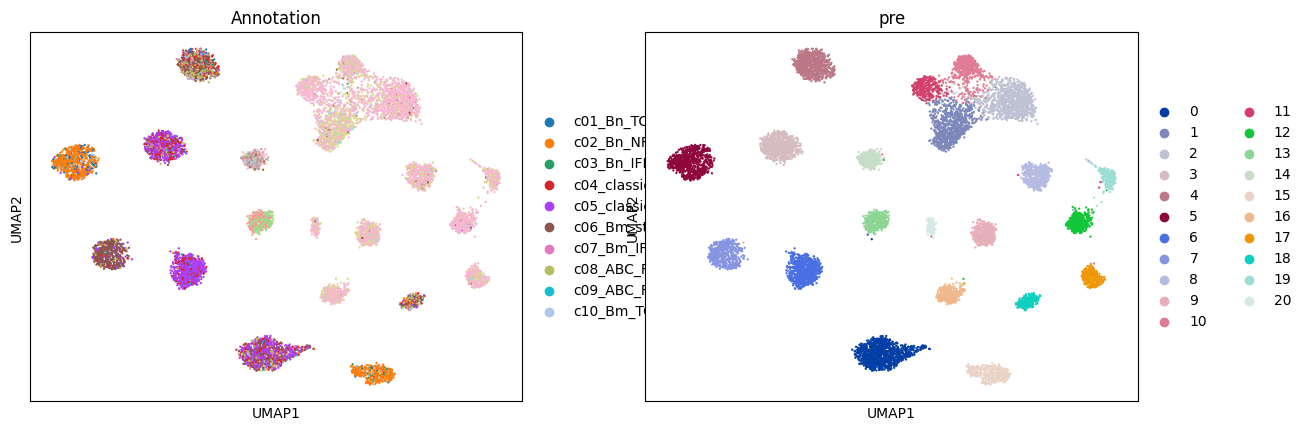

In [22]:
adata_ESCA_train.var_names_make_unique()
sc.pp.log1p(adata_ESCA_train)
sc.pp.neighbors(adata_ESCA_train, use_rep='cell_emb')
sc.tl.umap(adata_ESCA_train)
sc.pl.umap(adata_ESCA_train, color=['Annotation', 'pre'], show=True)

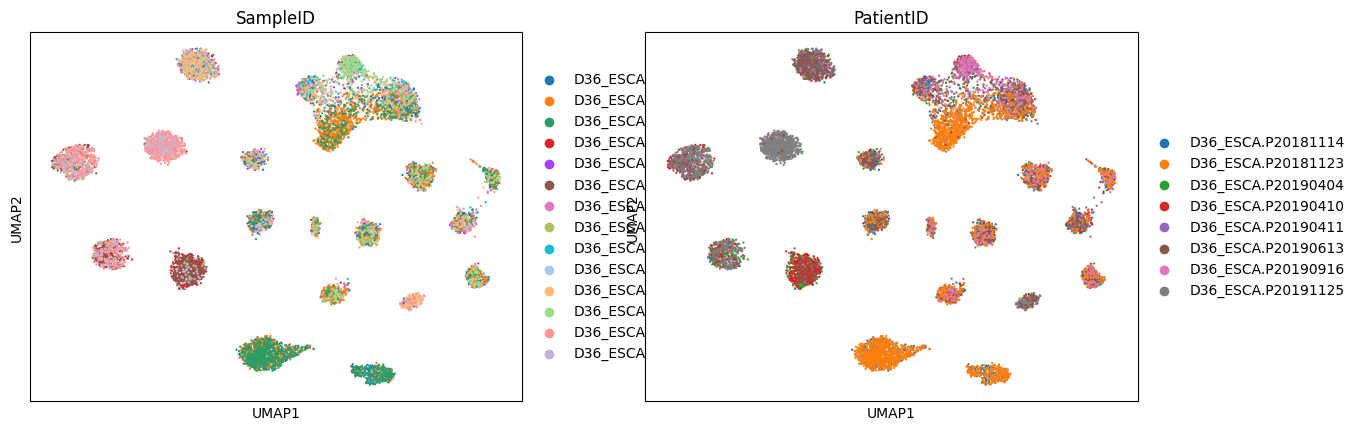

In [23]:
sc.pl.umap(adata_ESCA_train, color=['SampleID', 'PatientID'], show=True)

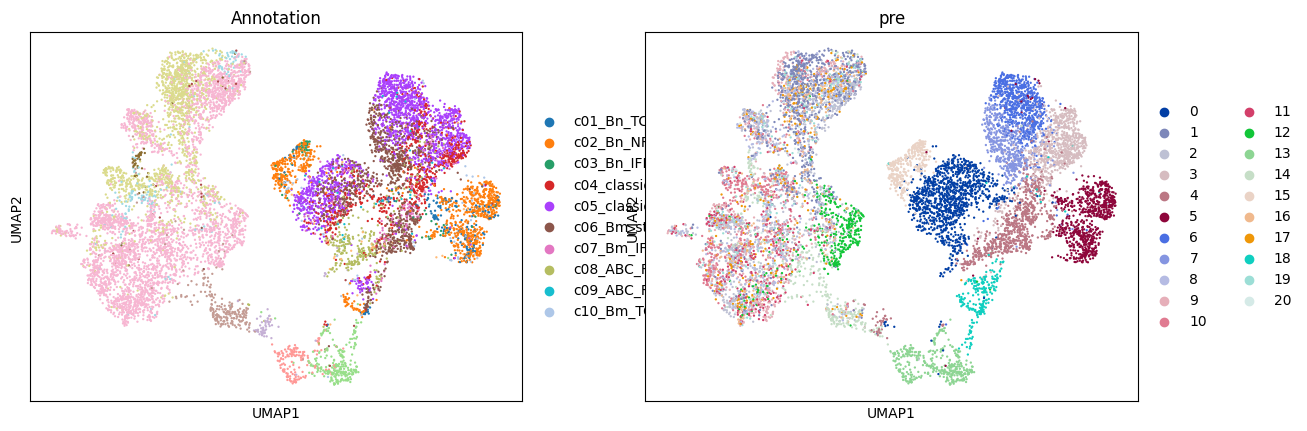

In [24]:
sc.pp.filter_cells(adata_ESCA_train, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
# adata.var['mt'] = adata.var_names.str.startswith('MT-')
# sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
# sc.pl.violin(adata, ['n_genes', 'n_counts', 'percent_mt'], jitter=0.4)

# 标准化和识别高度变异基因
sc.pp.normalize_total(adata_ESCA_train, target_sum=1e4)
sc.pp.log1p(adata_ESCA_train)
# sc.pp.highly_variable_genes(adata_ESCA_train, min_mean=0.0125, max_mean=3, min_disp=0.5)
# adata = adata[:, adata.var['highly_variable']]
# sc.pl.highly_variable_genes(adata_ESCA_train)

# PCA
sc.pp.scale(adata_ESCA_train, max_value=10)
sc.tl.pca(adata_ESCA_train, svd_solver='arpack')
# sc.pl.pca_variance_ratio(adata_ESCA_train, log=True, n_pcs=50)

# 邻接图
sc.pp.neighbors(adata_ESCA_train, n_neighbors=10, n_pcs=40)

# UMAP
sc.tl.umap(adata_ESCA_train)
sc.pl.umap(adata_ESCA_train, color=['Annotation','pre'])

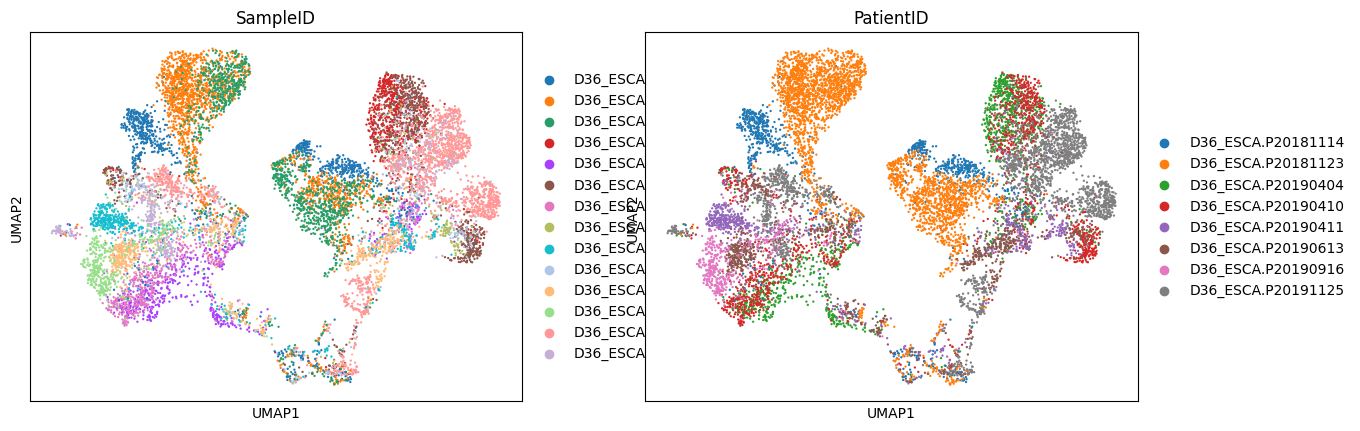

In [25]:
sc.pl.umap(adata_ESCA_train, color=['SampleID', 'PatientID'], show=True)